In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [53]:
housing = fetch_california_housing()
data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

In [54]:
X=data[['AveRooms']].values
y=data['Price'].values

In [55]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [56]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
w = 0
b = 0
learning_rate = 0.01
epochs = 1000
cost_history=[]
n = len(X_train_scaled)
x = X_train_scaled.flatten()
for i in range(epochs):
    y_pred = w * x + b
    cost = (1/(2*n)) * np.sum((y_pred - y_train)**2)
    cost_history.append(cost)
    dw = (1/n) * np.sum((y_pred - y_train) * x)
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")
y_pred_gd = w * X_test_scaled.flatten() + b
              
    
    

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [58]:
print("Gradient Descent")
print("-----------------")
print("Weight:",w)
print("Bias: ", b)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2Score:",r2_score(y_test,y_pred_gd))


Gradient Descent
-----------------
Weight: 0.18323090648660517
Bias:  2.0718574888450205
MSE: 1.292327655590046
R2Score: 0.013798228607320828


In [59]:
X_train_ne=np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test]
theta=np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta


In [60]:
print("\nNormal Equation")
print("-----------------")
print("Intercept:",theta[0])
print("slope: ",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2Score:",r2_score(y_test,y_pred_ne))



      


Normal Equation
-----------------
Intercept: 1.6547622685968417
slope:  0.07675558963126736
MSE: 1.2923314440807299
R2Score: 0.013795337532284901


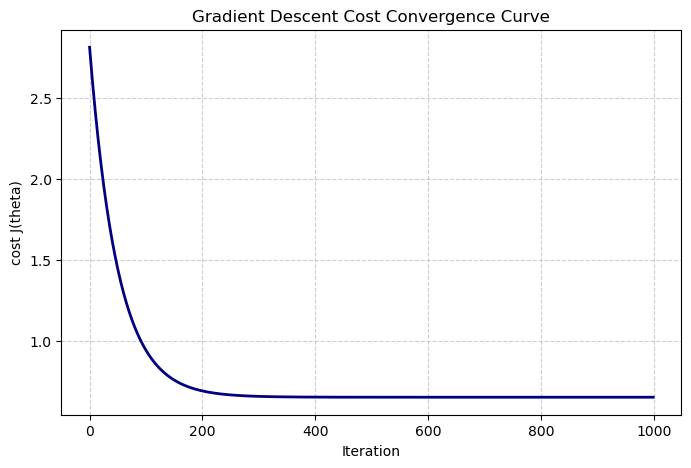

In [62]:
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title("Gradient Descent Cost Convergence Curve")
plt.xlabel('Iteration')
plt.ylabel('cost J(theta)')
plt.grid(True,linestyle='--',alpha=0.6)

plt.show()


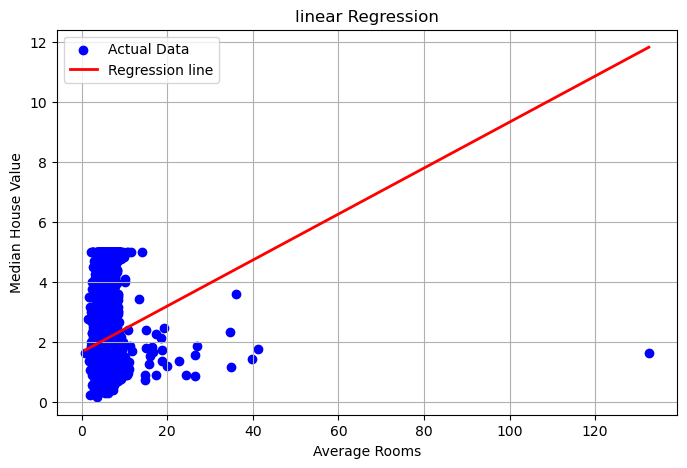

In [66]:
index =np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test,color='blue',label='Actual Data')
plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label="Regression line"
)
plt.title("linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()
